In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import export_graphviz
from IPython.display import Image
import pydotplus
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import KFold
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import cross_val_score
!pip install --upgrade xgboost
import xgboost as xgb
from xgboost import XGBRegressor



In [4]:
df = pd.read_csv("credit_risk.csv")

**Data Preocessing**

In [5]:
df.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


In [6]:
df.shape

(32581, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Id              32581 non-null  int64  
 1   Age             32581 non-null  int64  
 2   Income          32581 non-null  int64  
 3   Home            32581 non-null  object 
 4   Emp_length      31686 non-null  float64
 5   Intent          32581 non-null  object 
 6   Amount          32581 non-null  int64  
 7   Rate            29465 non-null  float64
 8   Status          32581 non-null  int64  
 9   Percent_income  32581 non-null  float64
 10  Default         32581 non-null  object 
 11  Cred_length     32581 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 3.0+ MB


In [8]:
df.columns

Index(['Id', 'Age', 'Income', 'Home', 'Emp_length', 'Intent', 'Amount', 'Rate',
       'Status', 'Percent_income', 'Default', 'Cred_length'],
      dtype='object')

In [9]:
df.dtypes

,0
Id,int64
Age,int64
Income,int64
Home,object
Emp_length,float64
Intent,object
Amount,int64
Rate,float64
Status,int64
Percent_income,float64


In [10]:
df.isnull().sum()

,0
Id,0
Age,0
Income,0
Home,0
Emp_length,895
Intent,0
Amount,0
Rate,3116
Status,0
Percent_income,0


In [11]:
df_new = df.applymap(lambda x: x if isinstance (x, (int, float)) and x >0 else x).dropna()

/tmp/ipython-input-483/185511387.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_new = df.applymap(lambda x: x if isinstance (x, (int, float)) and x >0 else x).dropna()


In [12]:
df_new.isnull().sum()

,0
Id,0
Age,0
Income,0
Home,0
Emp_length,0
Intent,0
Amount,0
Rate,0
Status,0
Percent_income,0


In [13]:
df.value_counts()

,,,,,,,,,,,,count
Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length,
32780,66,42000,RENT,2.0,MEDICAL,6475,9.99,0,0.15,N,30,1
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3,1
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,1
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3,1
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
18,23,113000,RENT,8.0,DEBTCONSOLIDATION,35000,18.25,1,0.31,N,4,1
17,23,92111,RENT,7.0,MEDICAL,35000,20.25,1,0.32,N,4,1
16,23,120000,RENT,0.0,EDUCATION,35000,7.90,0,0.29,N,4,1


In [14]:
df_new.head()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


In [15]:
df_new.tail()

,Id,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
32576,32576,57,53000,MORTGAGE,1.0,PERSONAL,5800,13.16,0,0.11,N,30
32577,32577,54,120000,MORTGAGE,4.0,PERSONAL,17625,7.49,0,0.15,N,19
32578,32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,35000,10.99,1,0.46,N,28
32579,32579,56,150000,MORTGAGE,5.0,PERSONAL,15000,11.48,0,0.10,N,26
32580,32780,66,42000,RENT,2.0,MEDICAL,6475,9.99,0,0.15,N,30


In [16]:
df_new.describe()

,Id,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length
count,28638.000000,28638.000000,2.863800e+04,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000,28638.000000
mean,16292.246456,27.727216,6.664937e+04,4.788672,9656.493121,11.039867,0.216600,0.169488,5.793736
std,9387.237677,6.310441,6.235645e+04,4.154627,6329.683361,3.229372,0.411935,0.106393,4.038483
min,0.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,8159.500000,23.000000,3.948000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,16283.500000,26.000000,5.595600e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,24434.750000,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,32780.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [17]:
df_new = df.drop(columns = ['Id']).dropna()

In [18]:
df_new.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4


**Exploratory Data Analysis**

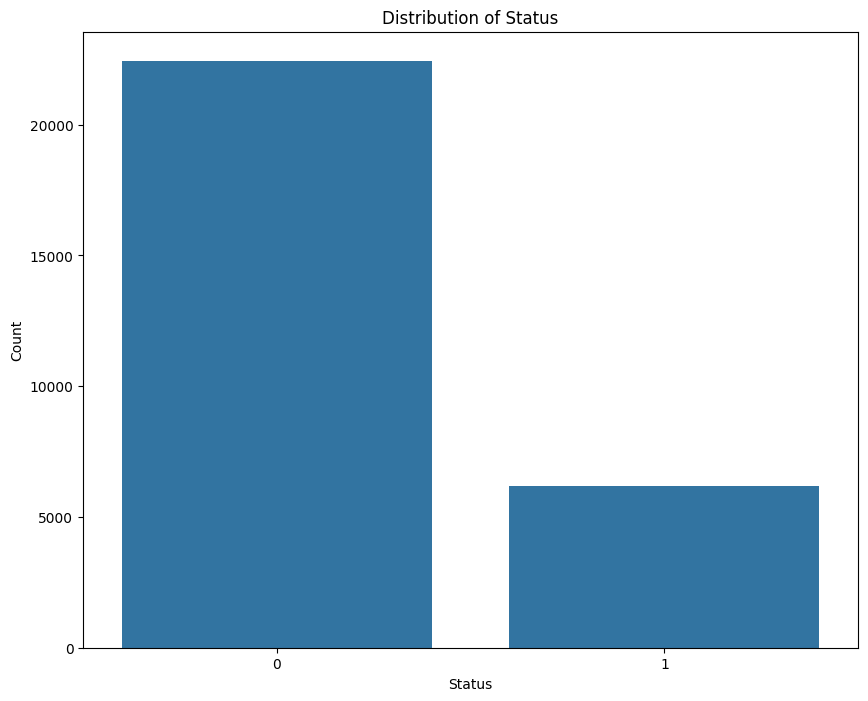

In [19]:
plt.figure(figsize= (10, 8))
sns.countplot(data= df_new, x= 'Status')
plt.xlabel('Status')
plt.ylabel('Count')
plt.title('Distribution of Status')
plt.show()

<Axes: xlabel='Intent', ylabel='Home'>

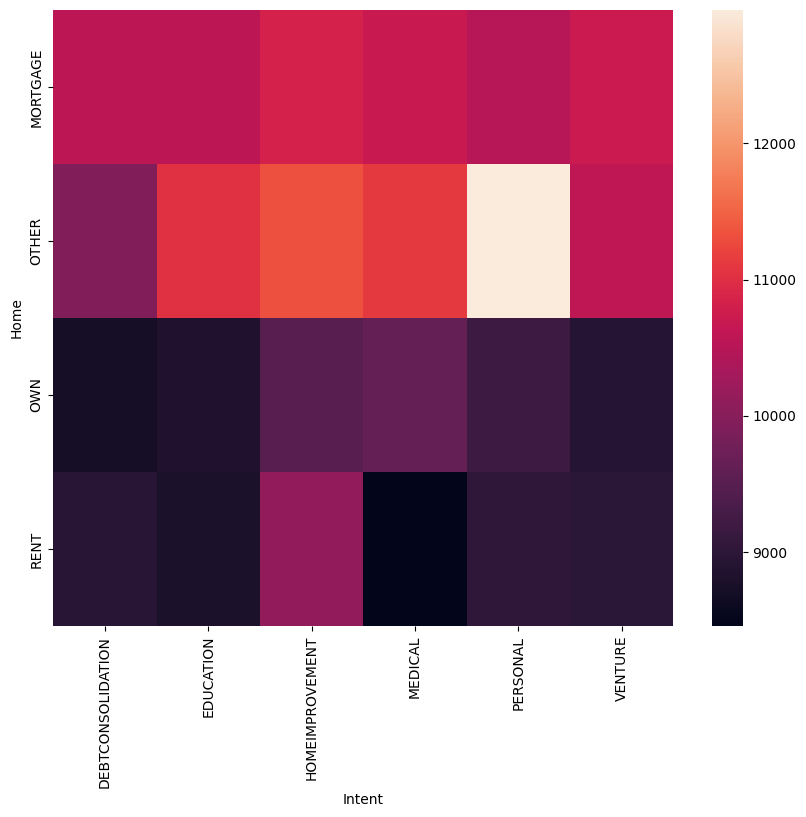

In [20]:
plt.figure(figsize= (10, 8))
pivot_table = df_new.pivot_table(index= 'Home', columns= 'Intent', values= 'Amount', aggfunc= 'mean')
sns.heatmap(pivot_table)

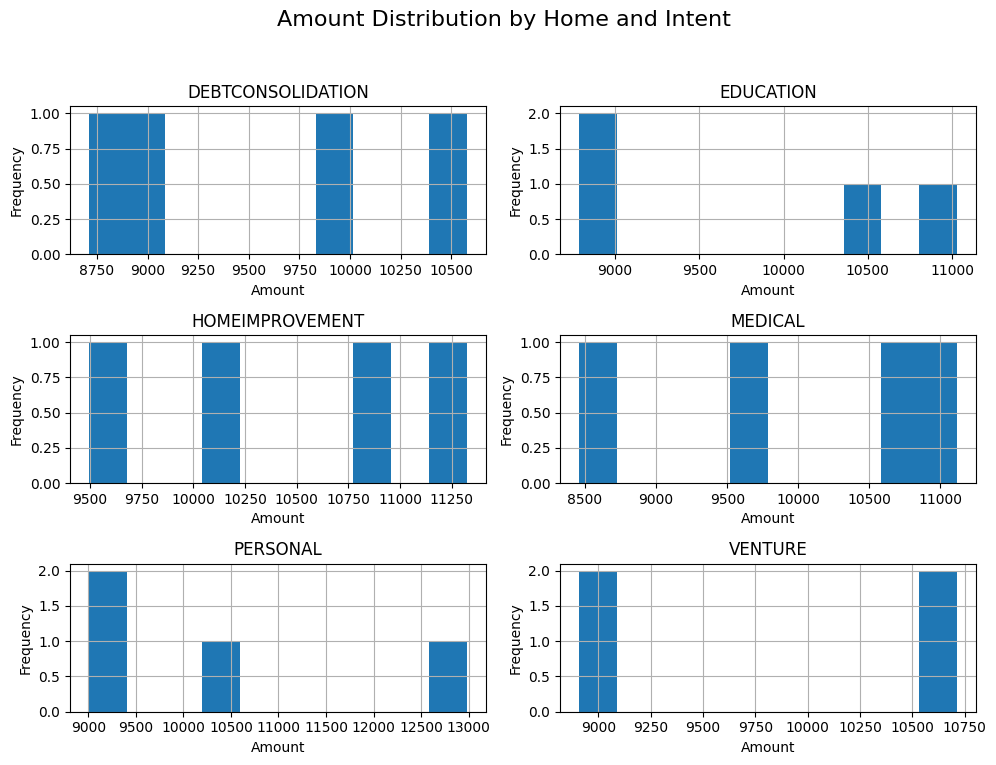

In [21]:
axes_array = pivot_table.hist(figsize= (10, 8))
fig = axes_array.flatten()[0].figure

fig.suptitle('Amount Distribution by Home and Intent', fontsize=16)

for ax in axes_array.flatten():
    ax.set_xlabel('Amount')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Text(0.5, 1.0, 'Age vs Amount')

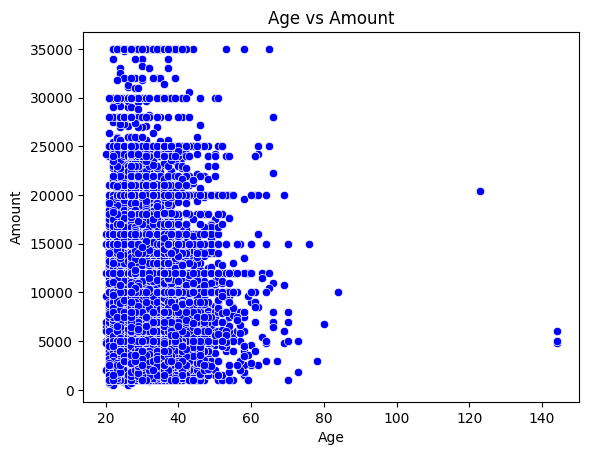

In [22]:
sns.scatterplot(x = 'Age', y= 'Amount', data= df_new, color = 'blue')
plt.title('Age vs Amount')

<Axes: xlabel='Emp_length', ylabel='Age'>

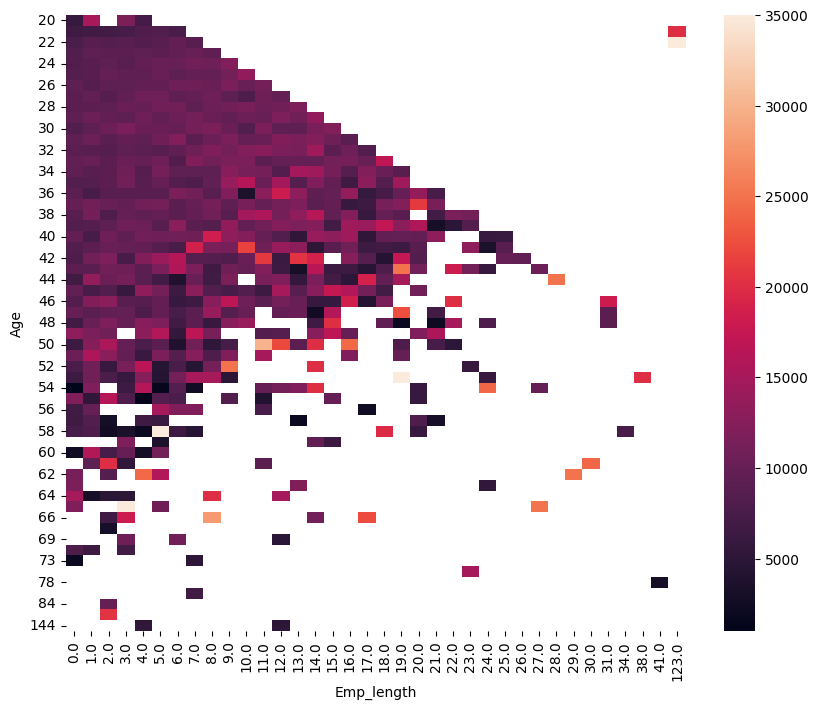

In [24]:
plt.figure(figsize= (10, 8))
pivot_table2 = df_new.pivot_table(index= 'Age', columns= 'Emp_length', values= 'Amount', aggfunc= 'mean')
sns.heatmap(pivot_table2)

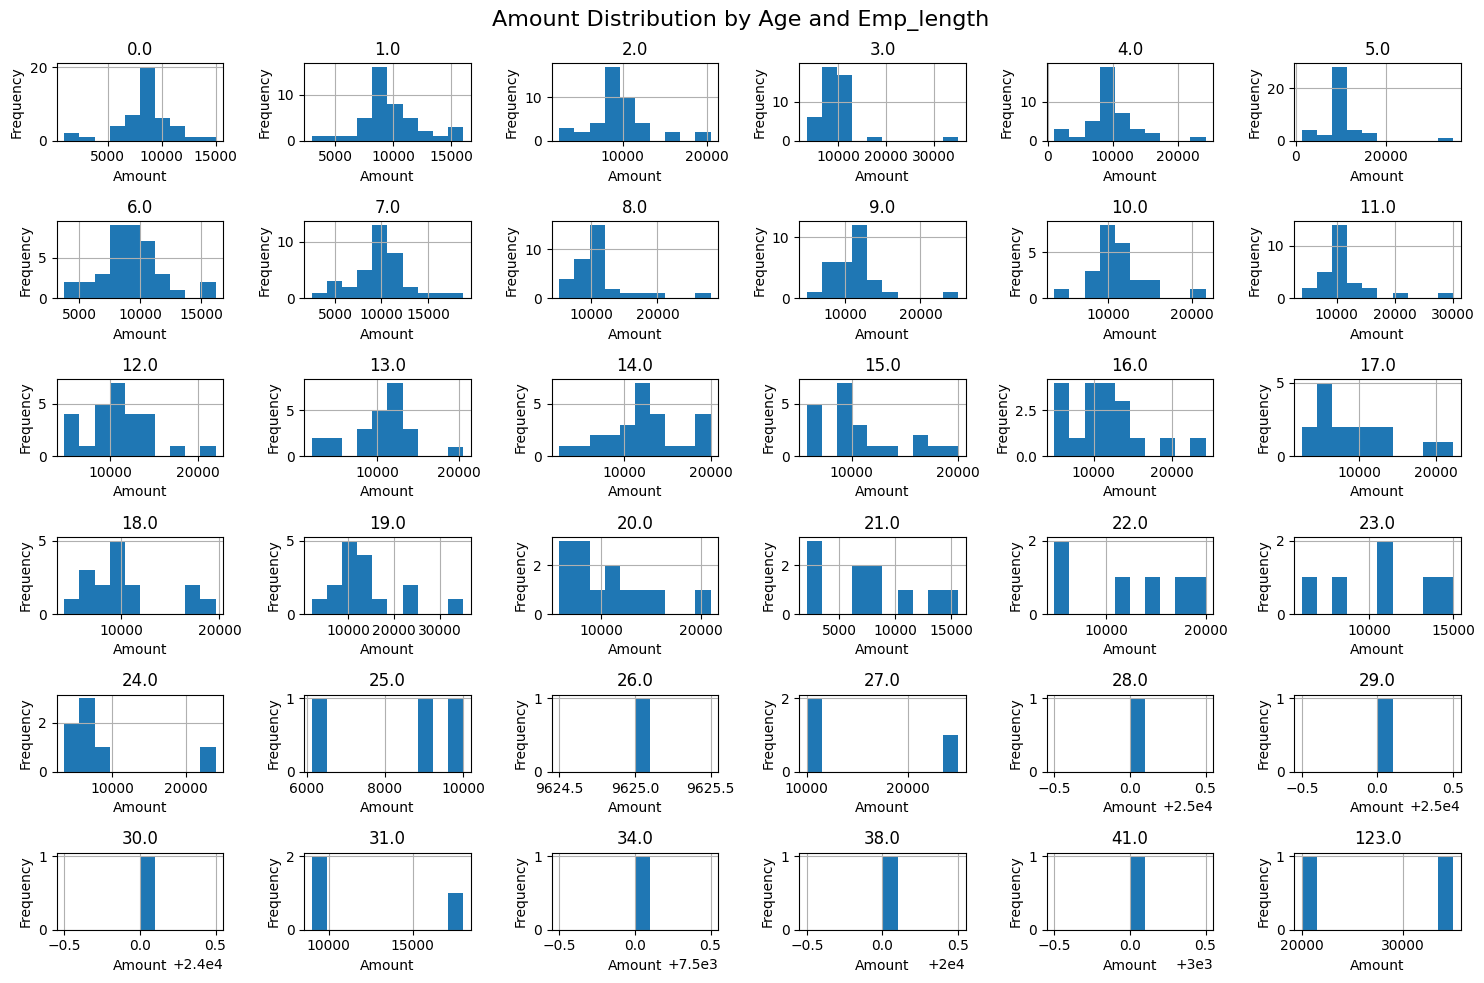

In [25]:
axes_array = pivot_table2.hist(figsize=(15, 10))
fig = axes_array.flatten()[0].figure

fig.suptitle('Amount Distribution by Age and Emp_length', fontsize=16)

for ax in axes_array.flatten():
    ax.set_xlabel('Amount')
    ax.set_ylabel('Frequency')

plt.tight_layout(rect=[0, 0.002, 1, 1])
plt.show()

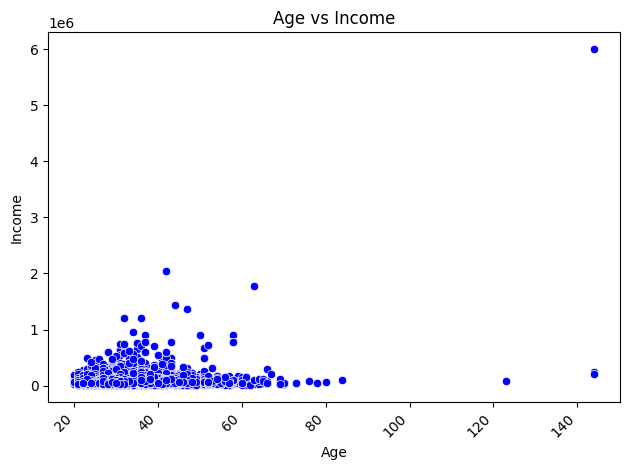

In [26]:
sns.scatterplot(x = 'Age', y= 'Income', data= df_new, color = 'blue')
plt.xlabel('Age')
plt.ylabel('Income')
plt.title('Age vs Income')
plt.xticks(rotation = 45, ha= 'right')
plt.tight_layout()
plt.show()

In [27]:
df_pairplot = df_new[['Age', 'Income', 'Amount', 'Rate', 'Percent_income', 'Status']]
df_pairplot.head()

,Age,Income,Amount,Rate,Percent_income,Status
0,22,59000,35000,16.02,0.59,1
1,21,9600,1000,11.14,0.10,0
2,25,9600,5500,12.87,0.57,1
3,23,65500,35000,15.23,0.53,1
4,24,54400,35000,14.27,0.55,1


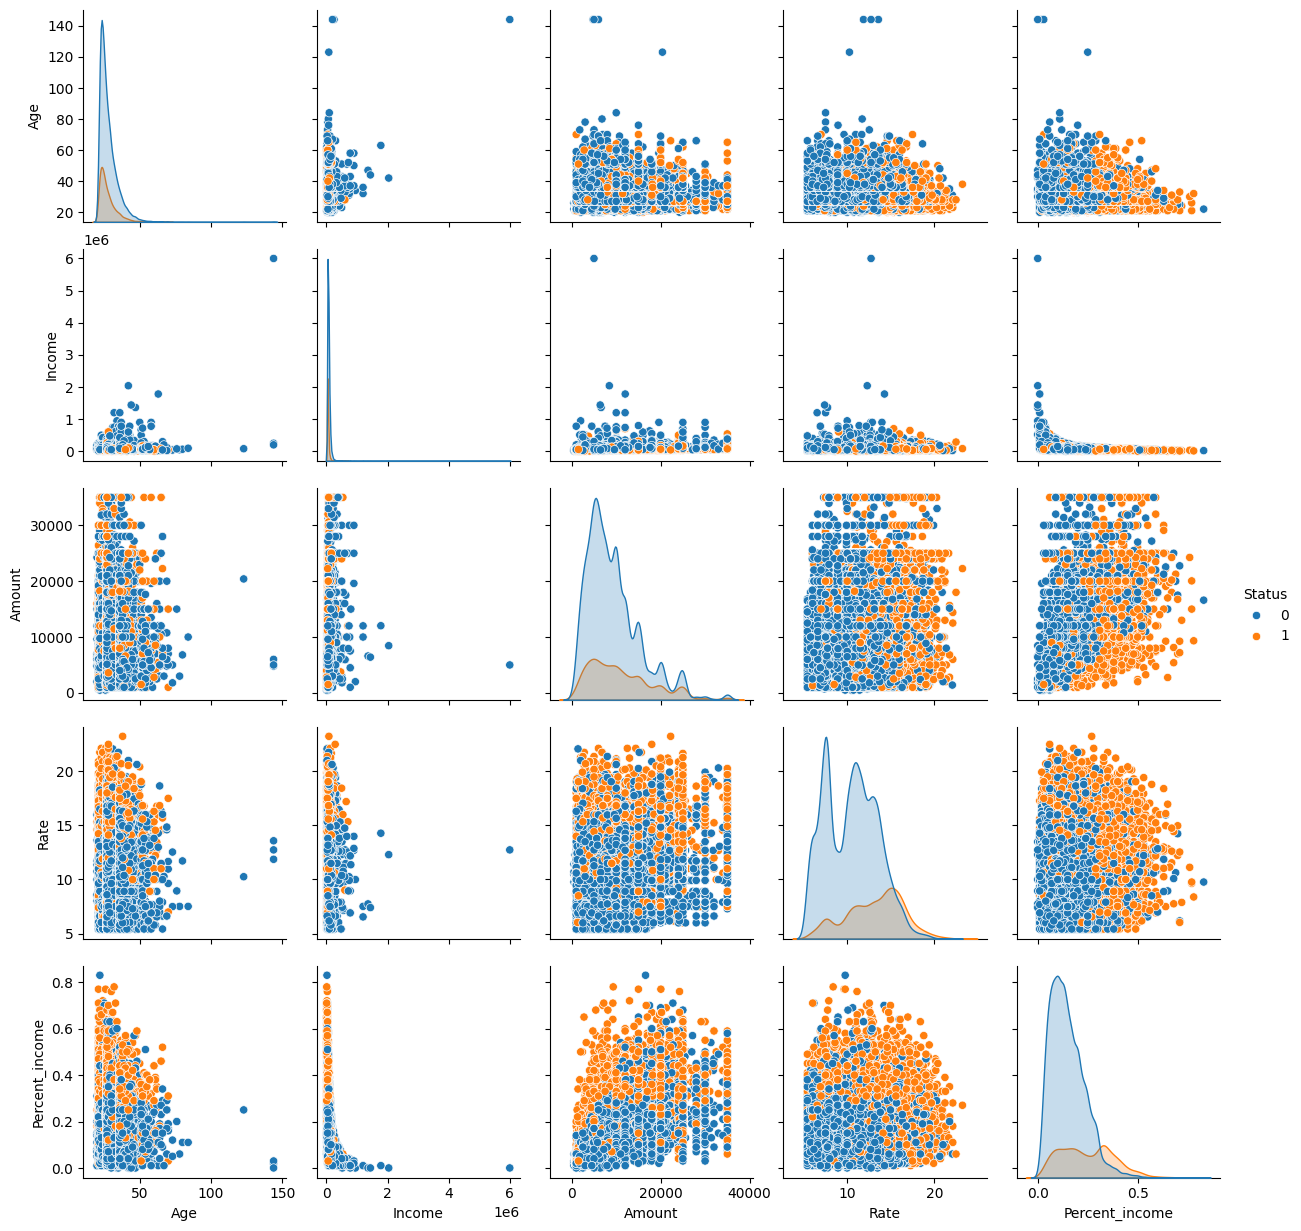

In [28]:
sns.pairplot(data= df_pairplot, hue = 'Status')
plt.show()

### Summary of Insights from Pair Plot

- **Age vs. Income**: There doesn't appear to be a clear linear relationship between age and income. However, there are some observations regarding 'Status' at different income and age levels. Borrowers with 'Status' 1 (red) seem to be present across various age and income groups, but there might be a higher concentration of 'Status' 0 (blue) for lower income individuals.

- **Amount vs. Income/Age**: The 'Amount' borrowed seems to be positively correlated with 'Income', especially for 'Status' 1. There are several instances of high loan amounts for individuals with higher incomes, particularly among those with 'Status' 1. Age doesn't show a strong direct correlation with 'Amount'.

- **Rate vs. Income/Age/Amount**: The 'Rate' appears to be higher for individuals with lower incomes and lower loan amounts, and vice-versa. There's a notable spread of 'Rate' for both 'Status' 0 and 'Status' 1 across different income and loan amounts.

- **Percent_income**: This feature shows a strong relationship with 'Status'. A higher 'Percent_income' (loan amount as a percentage of income) seems to correlate with 'Status' 1 (potentially indicating higher risk or difficulty in repayment). This is visible in the scatter plots where 'Percent_income' is on one of the axes, and also in the distribution plots on the diagonal.

- **Overall Impact of 'Status'**: The 'Status' column clearly differentiates the distributions and relationships among the numerical features. For example, individuals with 'Status' 1 tend to have higher 'Percent_income', and there are distinct clusters or spreads in other plots based on 'Status', suggesting that 'Status' is a significant factor in understanding credit risk.

**Loan Applicant Segmentation**

In [30]:
features_for_segmentation = ['Amount', 'Emp_length', 'Cred_length']
segmentation_data = df_new[features_for_segmentation].dropna()

n_clusters = 4
gmm = GaussianMixture(n_components=n_clusters, random_state=42)
gmm.fit(segmentation_data)

cluster_labels = gmm.predict(segmentation_data)

df_new.loc[segmentation_data.index, 'Cluster'] = cluster_labels
segment_means = df_new.groupby('Cluster')[features_for_segmentation].mean()
print(segment_means)

               Amount  Emp_length  Cred_length
Cluster                                       
0.0       7777.493665    4.102492     3.023934
1.0       5994.097285    2.870527     8.219385
2.0      12017.999818    9.209777    11.085005
3.0      19722.550900    3.660962     4.864857


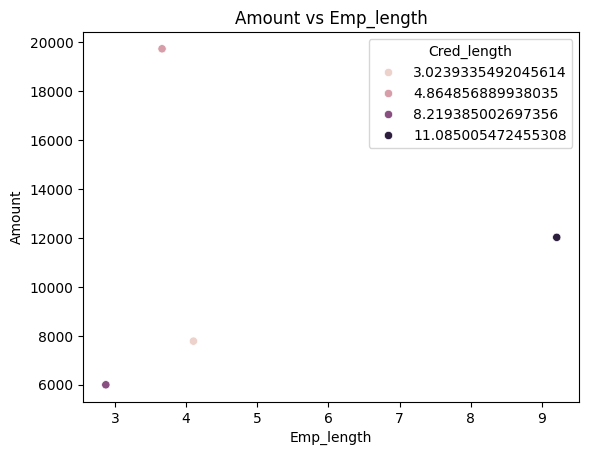

In [31]:
sns.scatterplot(x = 'Emp_length', y= 'Amount', hue = "Cred_length", data = segment_means)

plt.xlabel("Emp_length")
plt.ylabel("Amount")
plt.title("Amount vs Emp_length")
plt.show()

**Data Preprocessing**

In [32]:
df_new.head()

,Age,Income,Home,Emp_length,Intent,Amount,Rate,Status,Percent_income,Default,Cred_length,Cluster
0,22,59000,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3,2.0
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,0.0
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3,0.0
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2,3.0
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4,3.0


In [33]:
df_encoded= pd.get_dummies(df_new, columns=['Home','Intent', 'Default'], drop_first= True)

In [34]:
df_encoded.head()

,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length,Cluster,Home_OTHER,Home_OWN,Home_RENT,Intent_EDUCATION,Intent_HOMEIMPROVEMENT,Intent_MEDICAL,Intent_PERSONAL,Intent_VENTURE,Default_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,2.0,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,0.0,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.0,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,3.0,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,3.0,False,False,True,False,False,True,False,False,True


In [35]:
encoder = OneHotEncoder(sparse_output = False)

In [36]:
categorical_columns = ['Home', 'Intent', 'Default']
one_hot_encoded = encoder.fit_transform(df_new[categorical_columns])

In [37]:
one_hot_df = pd.DataFrame(one_hot_encoded, columns = encoder.get_feature_names_out(categorical_columns))

In [38]:
df_encoded = pd.get_dummies(df_new, columns=['Home','Intent', 'Default'], drop_first=True)

In [39]:
df_encoded.head()

,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length,Cluster,Home_OTHER,Home_OWN,Home_RENT,Intent_EDUCATION,Intent_HOMEIMPROVEMENT,Intent_MEDICAL,Intent_PERSONAL,Intent_VENTURE,Default_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,2.0,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,0.0,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.0,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,3.0,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,3.0,False,False,True,False,False,True,False,False,True


In [115]:
scaler = StandardScaler()
scaled_data= scaler.fit_transform(df_encoded)

In [40]:
X= df_encoded.drop('Default_Y', axis= 1)
y= df_encoded['Default_Y']

In [41]:
len(X), len(y)

(28638, 28638)

In [42]:
df_encoded.head()

,Age,Income,Emp_length,Amount,Rate,Status,Percent_income,Cred_length,Cluster,Home_OTHER,Home_OWN,Home_RENT,Intent_EDUCATION,Intent_HOMEIMPROVEMENT,Intent_MEDICAL,Intent_PERSONAL,Intent_VENTURE,Default_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,2.0,False,False,True,False,False,False,True,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,0.0,False,True,False,True,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,0.0,False,False,False,False,False,True,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,3.0,False,False,True,False,False,True,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,3.0,False,False,True,False,False,True,False,False,True


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state =42)

In [44]:
X_test.shape, X_train.shape, y_train.shape, y_test.shape

((5728, 17), (22910, 17), (22910,), (5728,))

**Decision Tree Model**

In [45]:
clf= DecisionTreeClassifier(criterion= "entropy", max_depth =3)
clf = clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

Accuracy: 0.82

Confusion Matrix:
 [[3811  907]
 [  96  914]]

Classification Report:
               precision    recall  f1-score   support

       False       0.98      0.81      0.88      4718
        True       0.50      0.90      0.65      1010

    accuracy                           0.82      5728
   macro avg       0.74      0.86      0.76      5728
weighted avg       0.89      0.82      0.84      5728



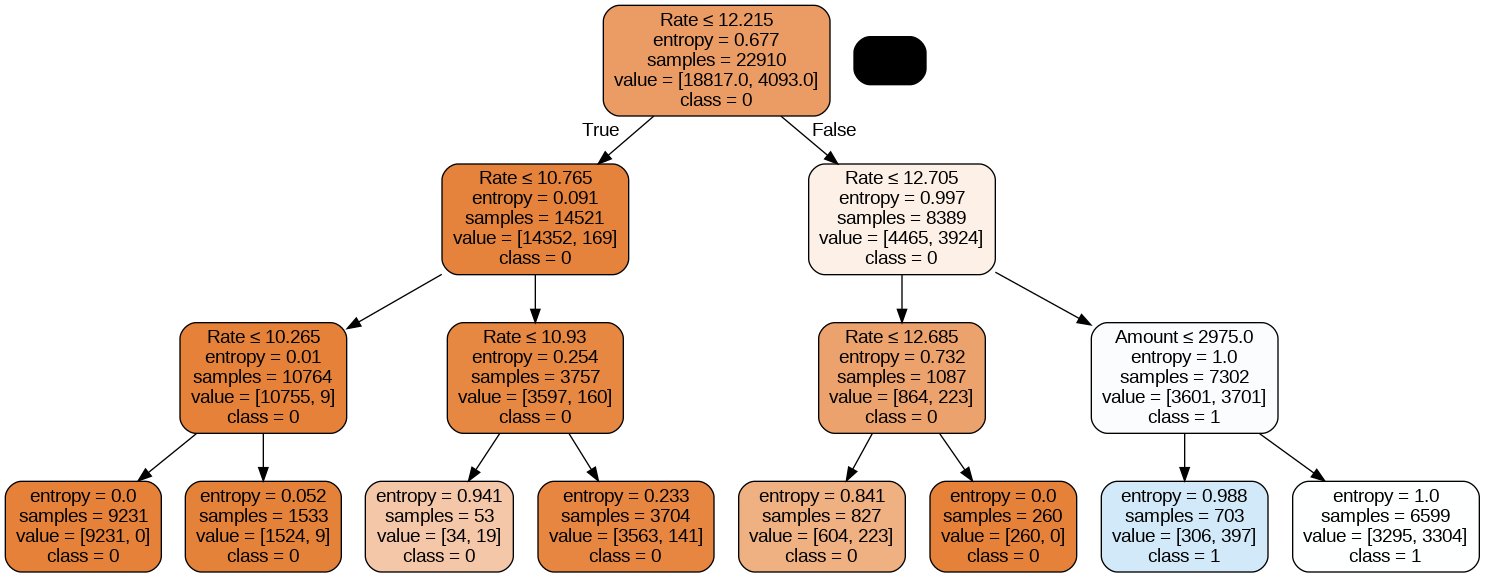

In [46]:
dot_data = StringIO()
feature_cols = X.columns
export_graphviz(clf, out_file= dot_data,
                filled= True, rounded = True ,
                special_characters= True, feature_names= feature_cols, class_names= ['0', '1'])
graph= pydotplus.graph_from_dot_data(dot_data.getvalue())
graph.write_png('Credit_Risk_Analysis.png')
Image(graph.create_png())

**XGBoost Regression**

In [54]:
model= xgb.XGBRegressor(objective = 'reg:squarederror', n_estimators = 100, random_state =  42)
model.fit(X_train, y_train)
y_pred2 =  model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred2))
r2 = r2_score(y_test, y_pred2)

print(f'RMSE: {rmse: .2f}')
print(f'R2: {r2:.3f}')

RMSE:  0.32
R2: 0.304


In [ ]:
#RMSE  of a value of 0.42 is slightly high because the predicted values against actuals values has a higher error discrepancy
#R square is slightly lower at 30.0%, which is quite a low explanatory power \
#fit of the data is weak
#

In [55]:
y_pred2_binary = (y_pred2 > 0.5).astype(int)
print(f'Accuracy: {accuracy_score(y_test, y_pred2_binary):.2f}')
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred2_binary))
print('\nClassification Report:\n', classification_report(y_test, y_pred2_binary))

Accuracy: 0.83

Confusion Matrix:
 [[4248  470]
 [ 516  494]]

Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.90      0.90      4718
        True       0.51      0.49      0.50      1010

    accuracy                           0.83      5728
   macro avg       0.70      0.69      0.70      5728
weighted avg       0.82      0.83      0.83      5728



**RandomForest Classifier**

In [66]:
rfc =  RandomForestClassifier(random_state = 42)
rfc.fit(X_train, y_train)
y_pred3 = rfc.predict(X_test)
print('Model accuracy score with 10 decision-trees: {0:0.4f}'.format(accuracy_score(y_test, y_pred3)))

Model accuracy score with 10 decision-trees: 0.8261


In [67]:
y_pred3_binary = (y_pred3 > 0.5).astype(int)
print(f'Accuracy: {accuracy_score(y_test, y_pred3_binary):.2f}')
print('\nConfusion Matrix:\n', confusion_matrix(y_test, y_pred3_binary))
print('\nClassification Report:\n', classification_report(y_test, y_pred3_binary))

Accuracy: 0.83

Confusion Matrix:
 [[4308  410]
 [ 586  424]]

Classification Report:
               precision    recall  f1-score   support

       False       0.88      0.91      0.90      4718
        True       0.51      0.42      0.46      1010

    accuracy                           0.83      5728
   macro avg       0.69      0.67      0.68      5728
weighted avg       0.81      0.83      0.82      5728



**ROC Curve**

Decision Tree probabilities: [0.         0.50068192 0.         0.50068192 0.50068192]
XGBoost scores: [0.00437532 0.33042595 0.00221201 0.87303567 0.55644476]
Random Forest probabilities: [0.   0.53 0.02 0.51 0.23]


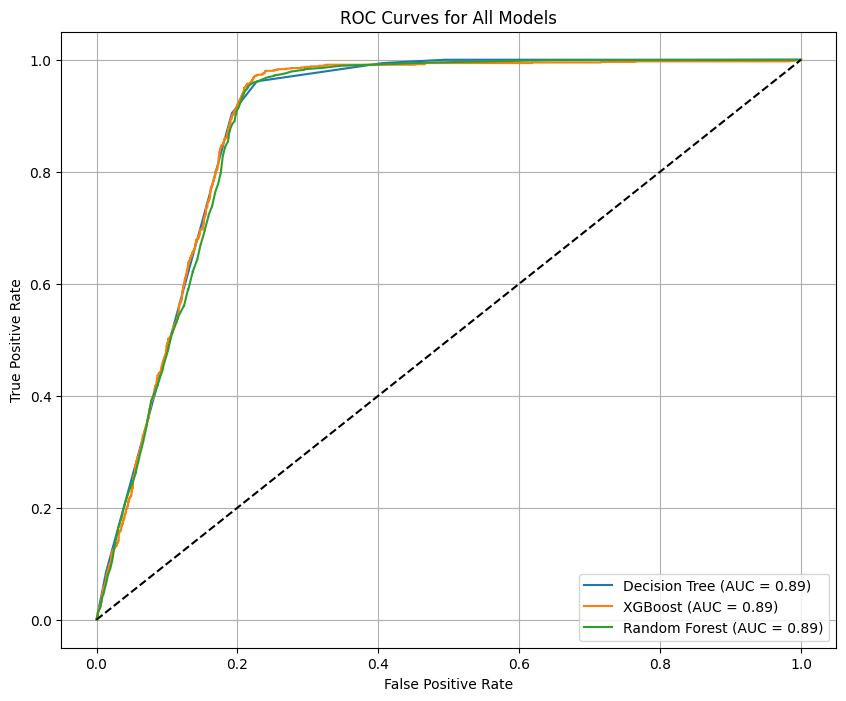

In [80]:
# Calculate the predicted probabilities/scores for each model
y_prob_dt = clf.predict_proba(X_test)[:, 1]
y_prob_xgb = model.predict(X_test)
y_prob_rf = rfc.predict_proba(X_test)[:, 1]

print("Decision Tree probabilities:", y_prob_dt[:5])
print("XGBoost scores:", y_prob_xgb[:5])
print("Random Forest probabilities:", y_prob_rf[:5])

# ROC Curve calculation
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_prob_dt)
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_prob_xgb)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

# AUCs
roc_auc_dt = roc_auc_score(y_test, y_prob_dt)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

# Plot ROC Curves
plt.figure(figsize=(10, 8))
plt.plot(fpr_dt, tpr_dt, label='Decision Tree (AUC = %0.2f)' % roc_auc_dt)
plt.plot(fpr_xgb, tpr_xgb, label='XGBoost (AUC = %0.2f)' % roc_auc_xgb)
plt.plot(fpr_rf, tpr_rf, label='Random Forest (AUC = %0.2f)' % roc_auc_rf)
# Plot the diagonal line
plt.plot([0, 1], [0, 1], 'k--')  # Diagonal line

# Labels and title
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')


plt.legend(loc="lower right")
plt.grid(True)
plt.show()

**Feature Engineering**

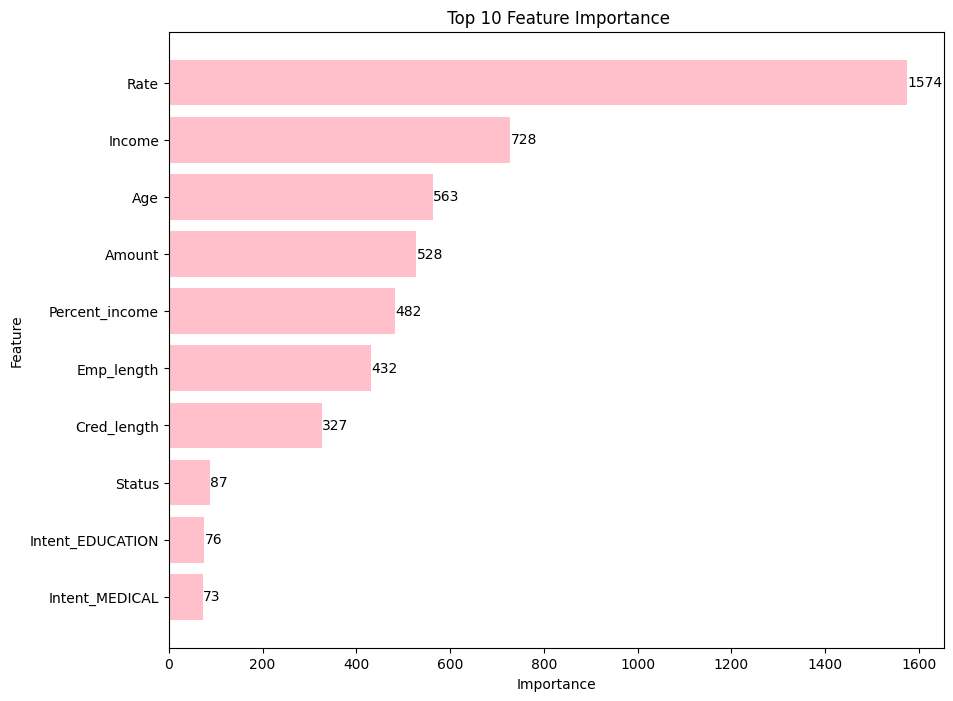

In [63]:
importance = model.get_booster().get_score(importance_type = 'weight')

importance_df = pd.DataFrame({
  'Feature': list(importance.keys()),
  'Importance': list(importance.values())
}).sort_values(by ='Importance', ascending = False)

top_n = 10
plt.figure(figsize =  (10, 8))
bars = plt.barh(
    importance_df['Feature'].head(top_n)[::-1],
    importance_df['Importance'].head(top_n)[::-1],
    color= 'pink'
)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title(f' Top {top_n} Feature Importance')

for bar in bars:
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{bar.get_width():.0f}',
             va='center', ha='left')

plt.show()

In [ ]:
#source
#<https://www.datacamp.com/tutorial/decision-tree-classification-python>